In [ ]:
import pandas as pd
df = pd.read_csv("../../data/train_data/pcf_dataset.csv")

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

import os

feature_cols = ["pcf_t_0.0200","pcf_t_0.0400","pcf_t_0.0600","pcf_t_0.0800",pcf_t_0.1000,pcf_t_0.1200,pcf_t_0.1400,pcf_t_0.1600,pcf_t_0.1800,pcf_t_0.2000,pcf_t_0.2200,pcf_t_0.2400,pcf_t_0.2600,pcf_t_0.2800,pcf_t_0.3000,pcf_t_0.3200,pcf_t_0.3400,pcf_t_0.3600,pcf_t_0.3800,pcf_t_0.4000,pcf_t_0.4200,pcf_t_0.4400,pcf_t_0.4600,pcf_t_0.4800,pcf_t_0.5000,pcf_t_0.5200,pcf_t_0.5400,pcf_t_0.5600,pcf_t_0.5800,pcf_t_0.6000,pcf_t_0.6200,pcf_t_0.6400,pcf_t_0.6600,pcf_t_0.6800,pcf_t_0.7000,pcf_t_0.7200,pcf_t_0.7400,pcf_t_0.7600,pcf_t_0.7800,pcf_t_0.8000,pcf_t_0.8200,pcf_t_0.8400,pcf_t_0.8600,pcf_t_0.8800,pcf_t_0.9000,pcf_t_0.9200,pcf_t_0.9400,pcf_t_0.9600,pcf_t_0.9800,pcf_t_1.0000]
cols_test = ['height', 'crown_volume', 'is_sapling', 'crown_diameter', 'stem_quality']
train_df = df[cols_test]


labels_df = pd.read_csv("../../data/train_data/labels.csv") 
label_df = labels_df["species"]               

X_train, X_test, y_train, y_test = train_test_split(train_df,label_df, test_size = 0.1, random_state = 42)



In [23]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)


In [24]:
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train,y_train)

y_pred = knn.predict(X_test)


In [25]:
print("--- Matrice de Confusion ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Rapport de Classification ---")
print(classification_report(y_test, y_pred))

--- Matrice de Confusion ---
[[ 2  0  0 ...  1  0  0]
 [ 0 66  2 ...  0  3  3]
 [ 1  3 22 ...  0  0  0]
 ...
 [ 0  0  1 ...  0  0  0]
 [ 0 14  0 ...  0  3  2]
 [ 0 10  0 ...  0  1  1]]

--- Rapport de Classification ---
                       precision    recall  f1-score   support

           Abies_alba       0.20      0.14      0.17        14
       Acer_campestre       0.31      0.54      0.39       123
  Acer_pseudoplatanus       0.27      0.39      0.32        57
       Acer_saccharum       0.09      0.10      0.10        10
       Betula_pendula       0.18      0.14      0.16        81
     Carpinus_betulus       0.16      0.18      0.17       119
     Corylus_avellana       0.00      0.00      0.00         4
   Crataegus_monogyna       0.12      0.08      0.10        24
   Eucalyptus_miniata       0.33      0.31      0.32        26
   Euonymus_europaeus       0.00      0.00      0.00        19
      Fagus_sylvatica       0.36      0.43      0.39       232
Fraxinus_angustifolia  

c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## Sélection des features les plus utiles avec SelectKBest
Nous allons utiliser SelectKBest pour identifier les variables les plus pertinentes pour la classification.

Scores des features :
crown_ratio: 63.03
height: 549.57
crown_volume: 135.36
crown_area: 219.85
crown_diameter: 170.88
trunk_height: 58.22
p10_height_rel: 118.82
p50_height_rel: 105.15
p90_height_rel: 117.55
stem_diameter: 8.28
stem_quality: 160.20
is_sapling: 16.28

Features sélectionnées : ['height', 'crown_volume', 'crown_area', 'crown_diameter', 'stem_quality']


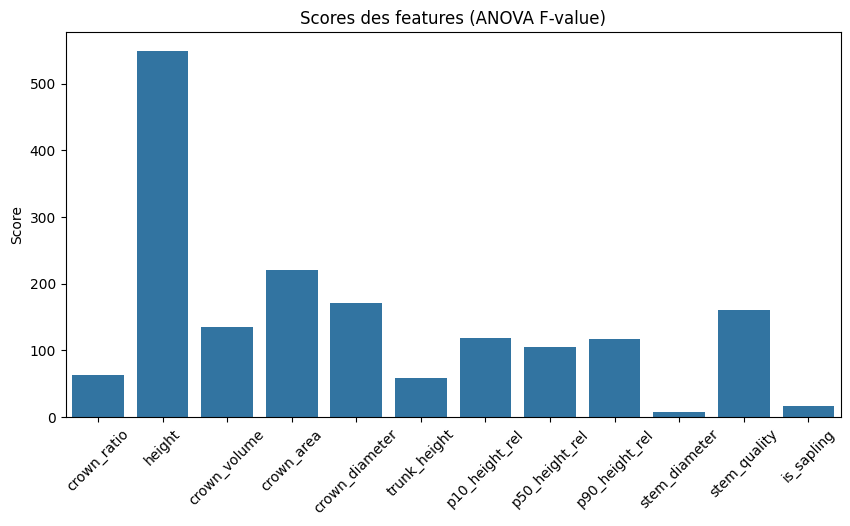

In [8]:
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import seaborn as sns

# Sélection des 5 meilleures features
selector = SelectKBest(score_func=f_classif, k=5)
selector.fit(X_train, y_train)
scores = selector.scores_
selected_features = [feature for feature, mask in zip(feature_cols, selector.get_support()) if mask]
print("Scores des features :")
for feature, score in zip(feature_cols, scores):
    print(f"{feature}: {score:.2f}")

print("\nFeatures sélectionnées :", selected_features)

# Visualisation des scores
plt.figure(figsize=(10,5))
sns.barplot(x=feature_cols, y=scores)
plt.xticks(rotation=45)
plt.title('Scores des features (ANOVA F-value)')
plt.ylabel('Score')
plt.show()